# Assignment 3: Predictive Analysis

Group 70: Michael Massaad (300293612) & Gabriel Zohrob (300309391)

Work Split:
- Gabriel Zohrob: Implemented Part 1: Regression Empirical Study with Linear Regression

- Michael Massaad: Implemented Part 2: Classification Empirical Study with Decision Trees

## Part 1: Regression Empirical Study with Linear Regression

### 1. Description of the Car Price Prediction Multiple Linear Regression

Link: https://www.kaggle.com/datasets/hellbuoy/car-price-prediction

Author: Manish Kumar

Purpose: The purpose of this dataset is to provide information about different cars sold in the American automobile market and their characteristics. It contains technical and descriptive attributes of vehicles such as engine specifications, fuel type, mileage, horsepower, and other design features, along with their corresponding market prices. The dataset allows for the analysis of how different car attributes relate to vehicle pricing and helps explore the factors that influence the price of cars in the U.S. market.

Shape: 205 rows; 26 columns

Features:
1. car_ID : Unique identifier assigned to each car in the dataset : Numerical (identifier)
2. symboling : Insurance risk rating assigned to the car, where higher values indicate higher risk (-3 ; 3): Numerical
3. CarName : Name of the car including brand and model : Categorical
4. fueltype : Type of fuel used by the vehicle such as gas or diesel : Categorical
5. aspiration : Indicates whether the engine uses standard aspiration or turbocharging : Categorical
6. doornumber : Number of doors the car has (two or four) : Categorical
7. carbody : Body style of the car such as sedan, hatchback, convertible, wagon, or hardtop : Categorical
8. drivewheel : Type of drivetrain used by the car (front-wheel drive, rear-wheel drive, or four-wheel drive) : Categorical
9. enginelocation : Location of the engine in the vehicle (front or rear) : Categorical
10. wheelbase : Distance between the centers of the front and rear wheels measured in inches : Numerical
11. carlength : Overall length of the vehicle measured in inches : Numerical
12. carwidth : Width of the vehicle measured in inches : Numerical
13. carheight : Height of the vehicle measured in inches : Numerical
14. curbweight : Weight of the car without passengers or cargo : Numerical
15. enginetype : Design configuration of the engine (for example DOHC or OHV) : Categorical
16. cylindernumber : Number of cylinders in the engine : Categorical
17. enginesize : Size of the engine measured in cubic centimeters : Numerical
18. fuelsystem : Type of fuel delivery system used by the engine : Categorical
19. boreratio : Ratio between the cylinder bore diameter and piston stroke : Numerical
20. stroke : Distance the piston travels inside the engine cylinder : Numerical
21. compressionratio : Ratio indicating the compression level inside the engine cylinder : Numerical
22. horsepower : Engine power output measured in horsepower : Numerical
23. peakrpm : Maximum revolutions per minute the engine can reach : Numerical
24. citympg : Fuel efficiency of the car measured in miles per gallon in city driving conditions : Numerical
25. highwaympg : Fuel efficiency of the car measured in miles per gallon in highway driving conditions : Numerical
26. price : Selling price of the car and the target variable for the regression model : Numerical (target variable)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/michaelmassaad02/CSI4142_Assignment3/refs/heads/main/CarPrice_Assignment.csv"
df = pd.read_csv(url)

df.head()

df.shape

(205, 26)

### 2. Data Cleaning

Before performing any modeling, it is important to inspect the dataset and verify its quality. Data cleaning ensures that the dataset does not contain inconsistencies that could negatively affect the regression model. 

In this step, we examine the dataset structure, verify the data types of each feature, and check for missing values and duplicate rows. Detecting these issues early allows us to ensure that the dataset is reliable before continuing with the analysis.

Since we previously implemented data validation and cleaning methods in Assignment 2, we reuse the same general approach here to confirm that the dataset is suitable for modeling.

In [30]:
# ===============================
# 2. DATA CLEANING
# ===============================

# First, we inspect the size of the dataset
print("Dataset shape:", df.shape)


# Display all column names
print("\nColumn names:")
print(df.columns.tolist())


# Display dataset information
print("\nDataset information:")
df.info()


# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


# Check duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


# Remove duplicates
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:", df.shape)


# Summary statistics
print("\nSummary statistics:")
display(df.describe())


# This step verifies that numerical values fall within reasonable ranges

print("\nRange Check (Min / Max Values):")

range_check = df.describe().loc[["min", "max"]]
display(range_check) # Realize that all values fall under an acceptable range.


# Optional: Check for unrealistic values in key variables

print("\nBasic sanity checks:")

print("Any negative prices:", (df["price"] < 0).sum())
print("Any zero or negative horsepower:", (df["horsepower"] <= 0).sum())
print("Any zero or negative engine size:", (df["enginesize"] <= 0).sum())

Dataset shape: (205, 26)

Column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 no

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000



Range Check (Min / Max Values):


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
min,1.0,-2.0,86.6,141.1,60.3,47.8,1488.0,61.0,2.54,2.07,7.0,48.0,4150.0,13.0,16.0,5118.0
max,205.0,3.0,120.9,208.1,72.3,59.8,4066.0,326.0,3.94,4.17,23.0,288.0,6600.0,49.0,54.0,45400.0



Basic sanity checks:
Any negative prices: 0
Any zero or negative horsepower: 0
Any zero or negative engine size: 0


The dataset contains 205 observations and 26 variables. Inspection of the dataset shows that all columns have 205 non-null values, indicating that there are no missing values.

A duplicate check was also performed, and no duplicate rows were found, as the dataset shape remained (205, 26) after the check.

Overall, the dataset is clean and suitable for further preprocessing. The next step is to convert categorical variables into numerical form so they can be used in the regression model.

### 3. Categorical Feature Encoding

Since linear regression models require numerical input variables, the categorical features must be converted into numerical representations.

To achieve this, we apply **one-hot encoding**, which transforms each category into a binary indicator variable. Each new column represents whether an observation belongs to a specific category.

To avoid redundancy and reduce multicollinearity in the regression model, we drop the first category of each encoded variable.

In [31]:
# ===============================
# 3. CATEGORICAL FEATURE ENCODING
# ===============================

# Create a copy of the original dataset before encoding
# This allows us to keep the raw dataset if needed later

df_raw = df.copy()


# Apply one-hot encoding to convert categorical variables into numerical format
# drop_first=True removes the first category to avoid multicollinearity

df_encoded = pd.get_dummies(df, drop_first=True)


# Print dataset shapes before and after encoding
# This shows how many new columns were created

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)


# Display the first few rows of the encoded dataset
# This helps verify that encoding worked correctly

display(df_encoded.head())

Original dataset shape: (205, 26)
Encoded dataset shape: (205, 191)


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,2,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,3,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,4,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,5,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


After applying one-hot encoding, categorical variables are transformed into binary numerical features. This increases the number of columns in the dataset because each category is represented as a separate feature.

As a result, the dataset now contains only numerical variables, making it compatible with linear regression models.

With the dataset fully numerical, we can proceed to exploratory data analysis to better understand the relationships between variables and identify potential outliers.

### 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis allows us to better understand the distribution of the variables in the dataset and identify potential patterns or anomalies.

In this step, we analyze the numerical features using histograms and boxplots. Histograms help visualize the distribution of each variable, while boxplots allow us to detect potential outliers.

We also compute a correlation matrix to identify relationships between variables. Understanding these relationships is useful when building regression models, as strongly correlated features may influence the prediction of the target variable.

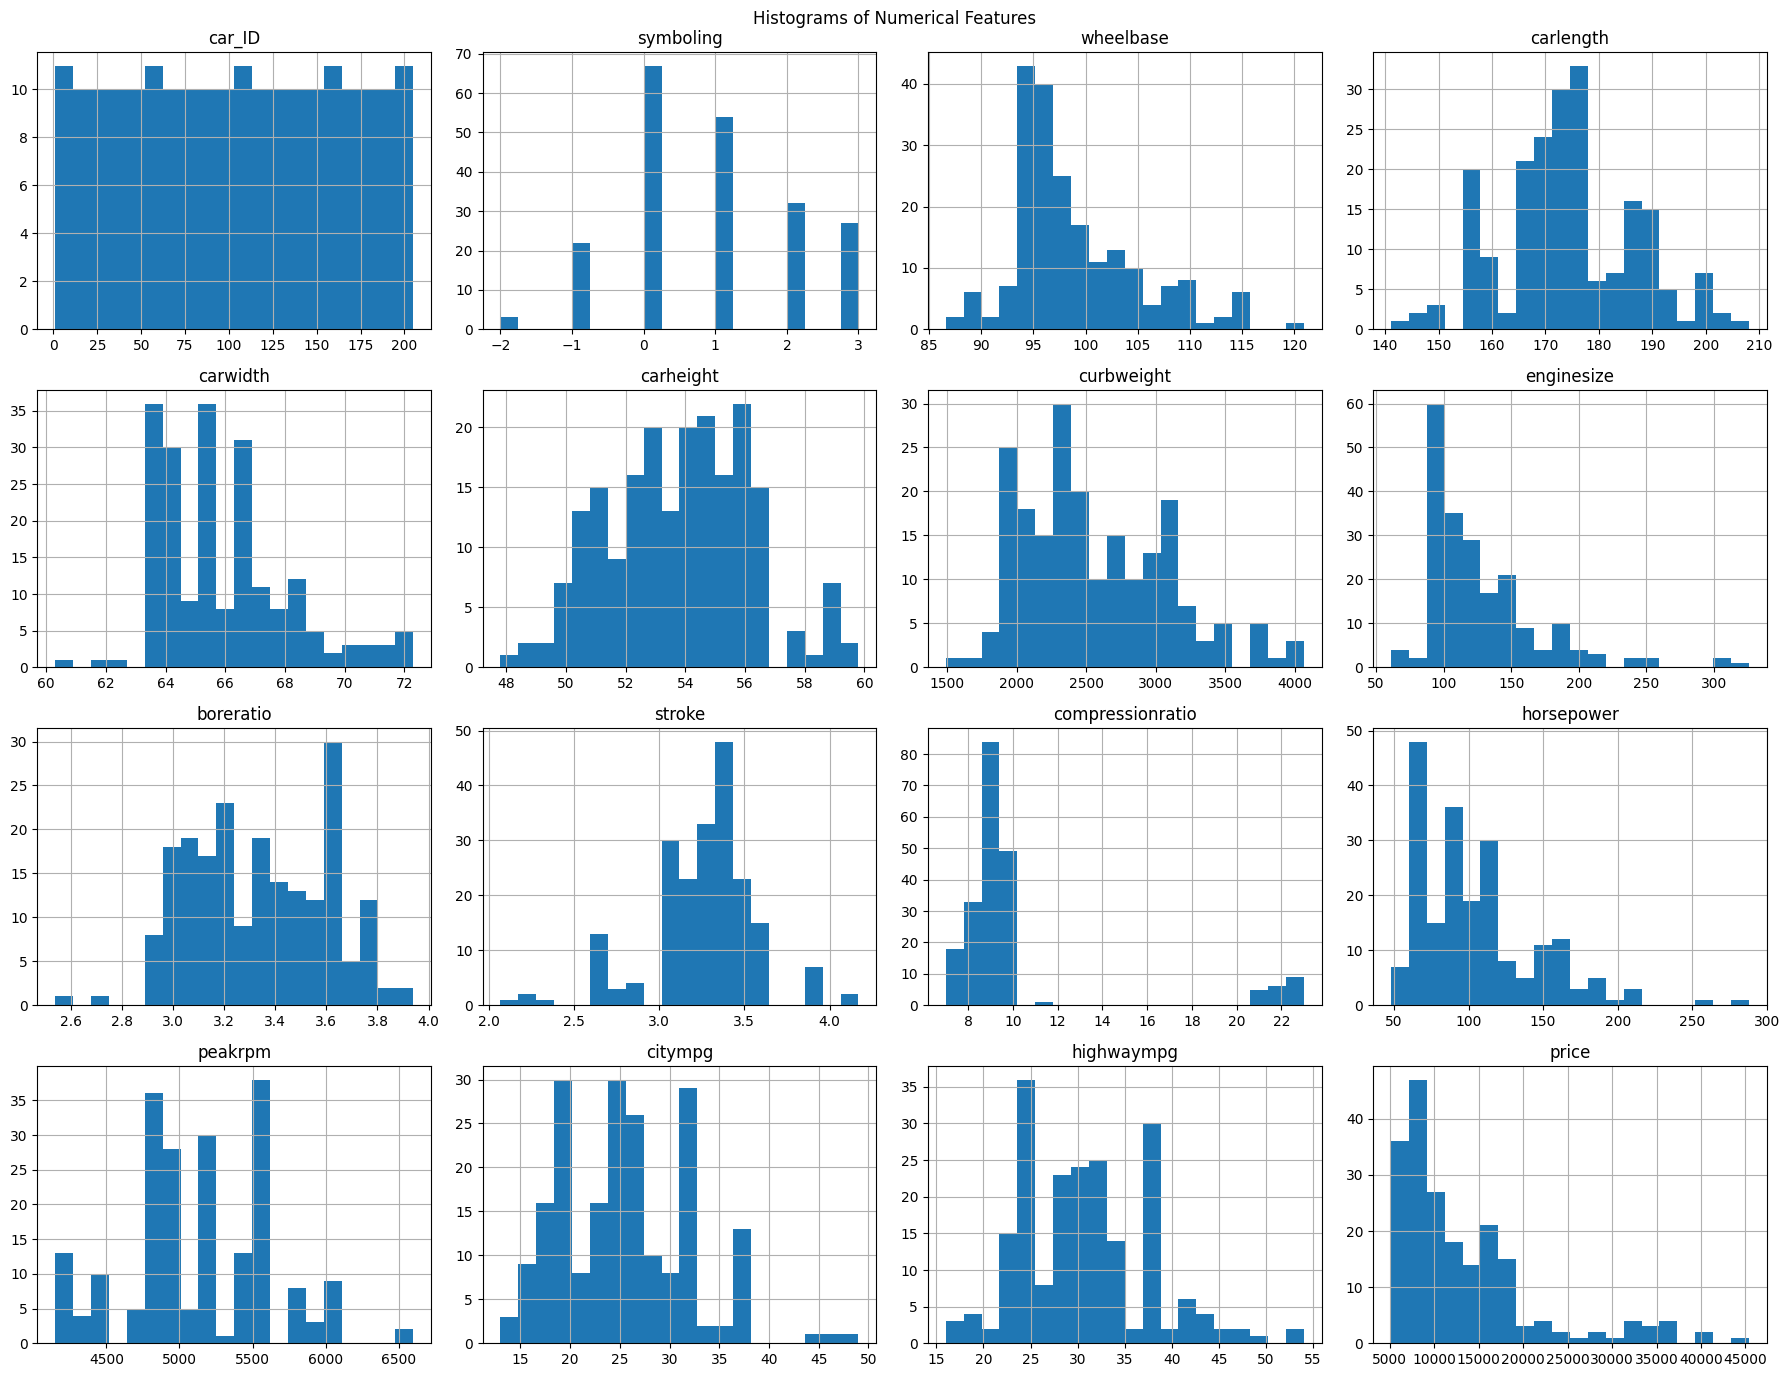

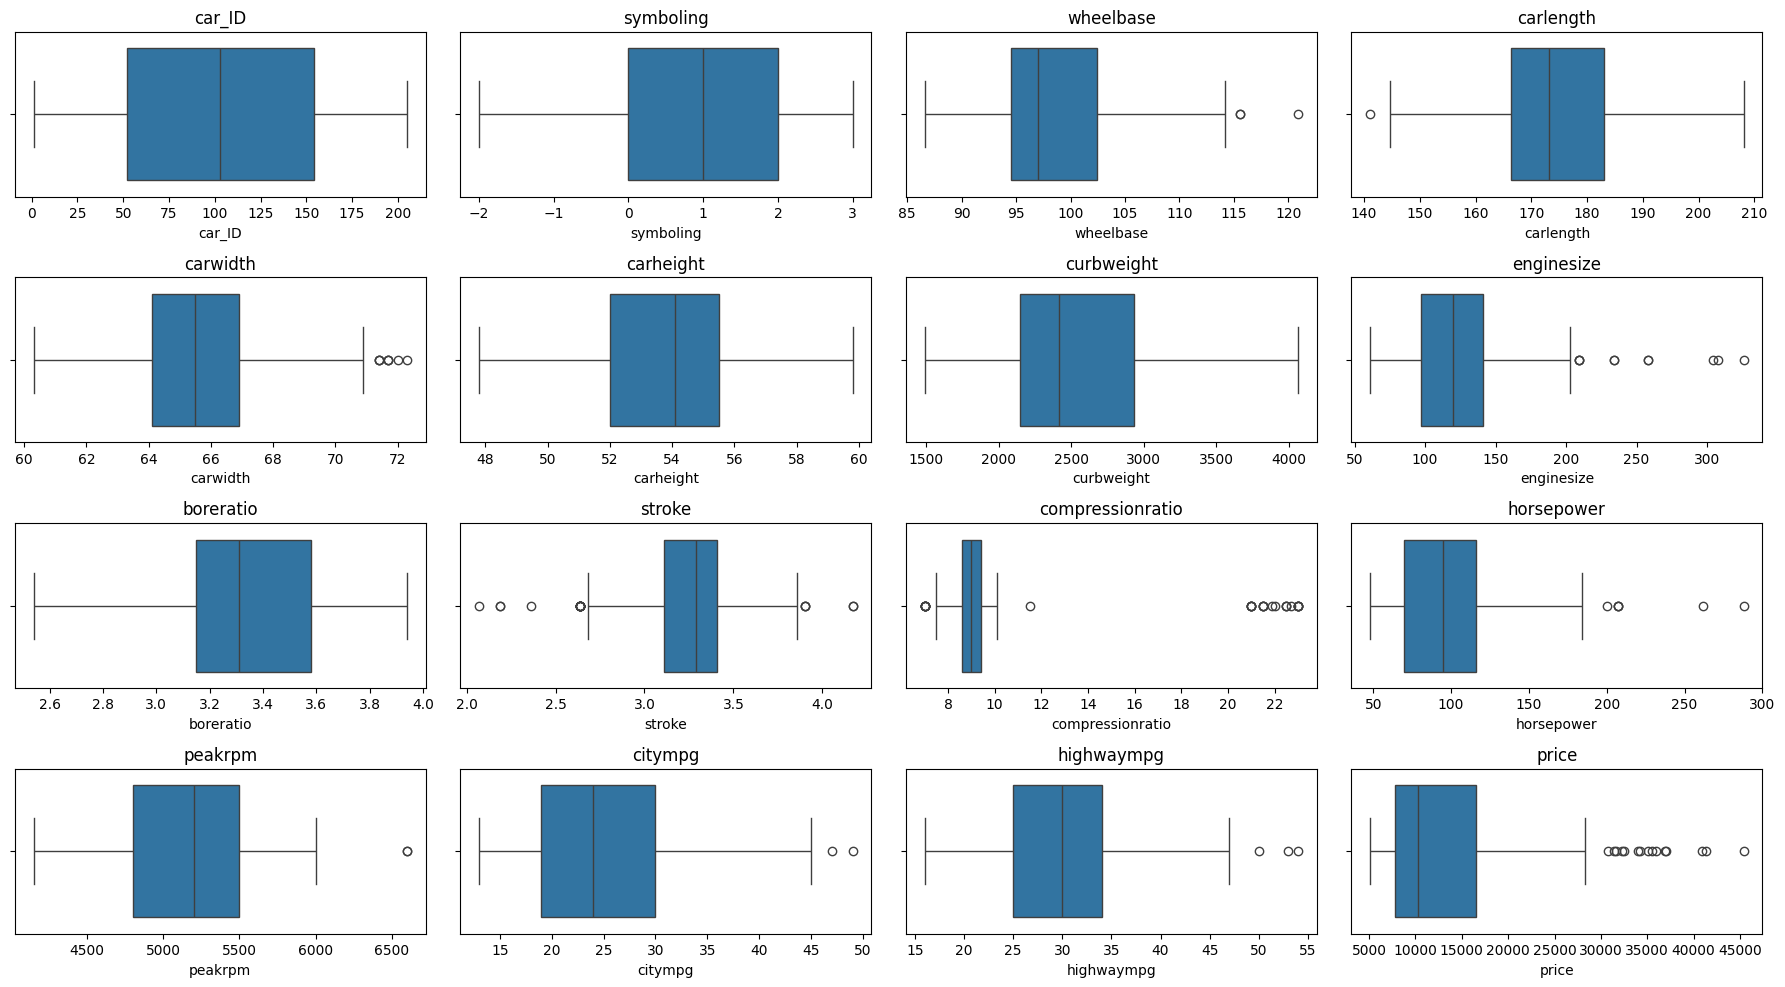

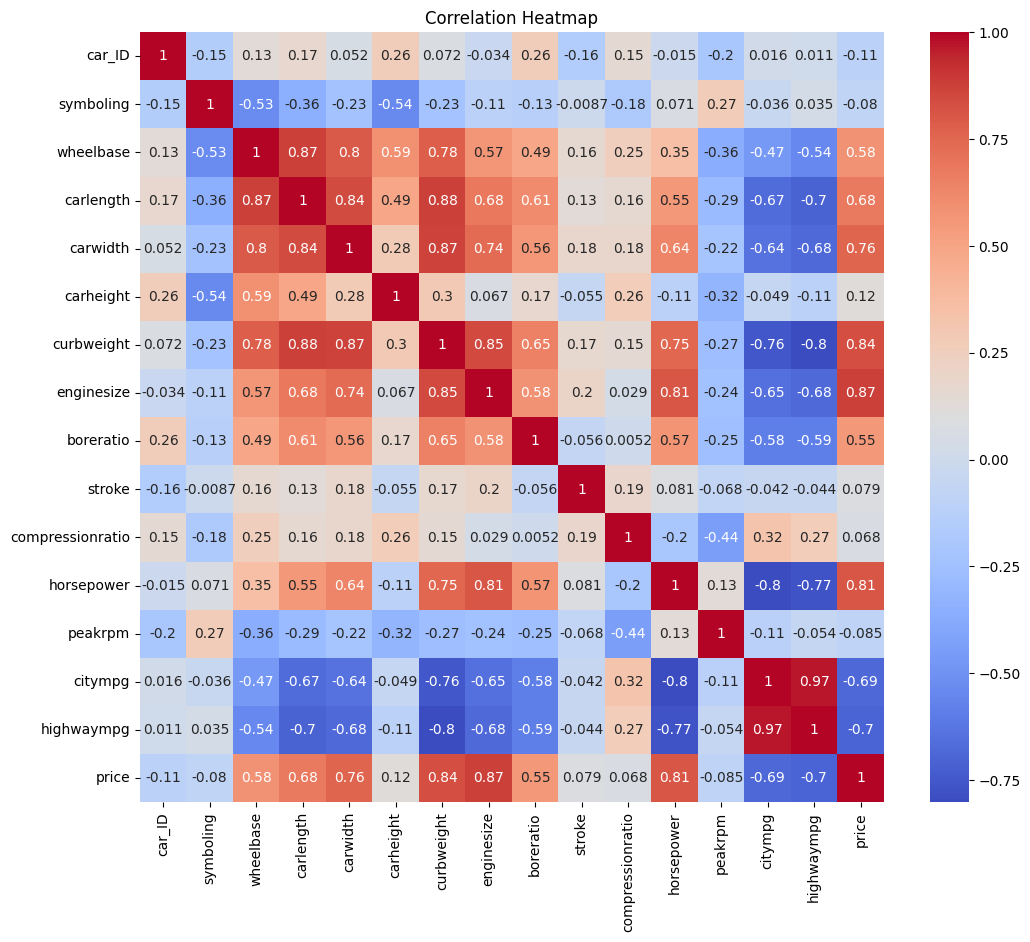

In [32]:
# ===============================
# 4. EXPLORATORY DATA ANALYSIS
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns


# Identify numerical columns in the dataset
# These will be used for plotting distributions and correlations

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


# -------------------------------
# HISTOGRAMS
# -------------------------------
# Histograms show the distribution of each numerical variable

df[numerical_cols].hist(figsize=(18,14), bins=20)

plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


# -------------------------------
# BOXPLOTS
# -------------------------------
# Boxplots help detect potential outliers in each feature

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):
    
    plt.subplot(5,4,i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


# -------------------------------
# CORRELATION MATRIX
# -------------------------------
# This heatmap shows relationships between numerical variables

plt.figure(figsize=(12,10))

corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

Observations from EDA

From the visualizations, we can observe the distribution of the numerical variables and identify potential extreme values. Variables such as price, horsepower, enginesize, and curbweight show large spreads and may contain outliers.

Since linear regression models are sensitive to extreme values, identifying outliers is an important step before building the model.

In the next step, we apply the **Local Outlier Factor (LOF)** algorithm to detect observations that differ significantly from their neighboring data points.

### 5. Outlier Detection using Local Outlier Factor (LOF)

Outliers are observations that differ significantly from the rest of the dataset. These extreme values can negatively affect linear regression models because linear regression minimizes squared error and is therefore very sensitive to unusually large deviations.

Following the assignment instructions, we apply the **Local Outlier Factor (LOF)** algorithm to detect potential outliers. LOF identifies observations that are locally isolated compared to their neighboring data points.

Based on the results from the exploratory data analysis, features such as `price`, `horsepower`, `enginesize`, and `curbweight` appear to contain potential extreme values. Since these variables are strongly related to car pricing, they are selected for LOF-based outlier detection.

After detecting outliers, we will create a version of the dataset with those observations removed so that we can later compare different model configurations.

In [33]:
# ===============================
# 5. OUTLIER DETECTION USING LOF
# ===============================

from sklearn.neighbors import LocalOutlierFactor

# Select numerical features that appeared to show possible outliers during EDA
# These features are strongly related to vehicle price and are relevant for regression
lof_features = df_encoded[["price", "horsepower", "enginesize", "curbweight"]].copy()

# Initialize the LOF model
# n_neighbors determines how many neighboring points are used to estimate local density
# contamination=0.05 assumes that around 5% of the data may be outliers
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# Fit LOF and predict outliers
# Output will be:
#  1  -> normal observation
# -1  -> outlier
lof_labels = lof.fit_predict(lof_features)

# Create a copy of the encoded dataset and store LOF labels
df_lof = df_encoded.copy()
df_lof["lof_outlier"] = lof_labels

# Count how many outliers were detected
num_outliers = (df_lof["lof_outlier"] == -1).sum()
print("Number of outliers detected by LOF:", num_outliers)

# Display a few detected outliers
print("\nSample detected outliers:")
display(df_lof[df_lof["lof_outlier"] == -1].head())

# Create a cleaned dataset where detected outliers are removed
df_no_outliers = df_lof[df_lof["lof_outlier"] == 1].drop(columns=["lof_outlier"])

# Compare dataset shapes before and after removing outliers
print("\nShape before LOF removal:", df_encoded.shape)
print("Shape after LOF removal:", df_no_outliers.shape)

Number of outliers detected by LOF: 11

Sample detected outliers:


,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,...,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi,lof_outlier
8,9,1,105.8,192.7,71.4,55.9,3086,131,3.13,3.40,...,False,False,False,False,False,False,True,False,False,-1
14,15,1,103.5,189.0,66.9,55.7,3055,164,3.31,3.19,...,False,False,False,False,False,False,True,False,False,-1
18,19,2,88.4,141.1,60.3,53.2,1488,61,2.91,3.03,...,False,False,True,False,False,False,False,False,False,-1
50,51,1,93.1,159.1,64.2,54.1,1890,91,3.03,3.15,...,False,False,True,False,False,False,False,False,False,-1
67,68,-1,110.0,190.9,70.3,56.5,3515,183,3.58,3.64,...,False,False,False,False,True,False,False,False,False,-1



Shape before LOF removal: (205, 191)
Shape after LOF removal: (194, 191)


The Local Outlier Factor algorithm detected **11 outliers** in the dataset. The dataset originally contained **205 observations**, and after removing the detected outliers the dataset size became **194 observations**.

This result is consistent with the LOF configuration, where the contamination parameter was set to **0.05**, meaning that approximately **5% of the dataset is expected to be classified as outliers**.

Removing these observations is reasonable because linear regression models are sensitive to extreme values. Outliers can disproportionately influence the fitted regression line and lead to poor generalization performance.

The cleaned dataset will therefore be used as one of the configurations in the empirical study to evaluate whether removing outliers improves the predictive performance of the regression model.

### 6. Feature Engineering

Feature engineering involves creating new variables from existing features in order to capture additional information that may improve the predictive performance of the regression model.

The assignment requires the creation of at least two aggregated features. These features are constructed using existing variables in the dataset and are designed to represent meaningful relationships that may influence vehicle pricing.

In this study, we introduce two additional features:

- **power_weight_ratio**: calculated as horsepower divided by curbweight. This feature reflects how powerful the engine is relative to the vehicle's weight.
- **engine_efficiency**: calculated as enginesize divided by horsepower. This feature captures a relationship between engine capacity and output power.

These aggregated variables may help the regression model better capture patterns related to performance and vehicle design.

In [34]:
# ===============================
# 6. FEATURE ENGINEERING
# ===============================

# Create a copy of the encoded dataset
# This ensures we keep the original encoded dataset unchanged
df_fe = df_encoded.copy()


# --------------------------------
# FEATURE 1: Power-to-weight ratio
# --------------------------------
# This feature measures how powerful the engine is relative to the vehicle's weight
# Higher values typically indicate higher performance vehicles

df_fe["power_weight_ratio"] = df_fe["horsepower"] / df_fe["curbweight"]


# --------------------------------
# FEATURE 2: Engine efficiency
# --------------------------------
# This feature represents the relationship between engine size and horsepower output
# It may capture efficiency differences across vehicles

df_fe["engine_efficiency"] = df_fe["enginesize"] / (df_fe["horsepower"] + 1e-6)


# Display the first rows of the new features
print("New engineered features:")
display(df_fe[["power_weight_ratio", "engine_efficiency"]].head())


# Check dataset shape after adding features
print("Dataset shape after feature engineering:", df_fe.shape)

New engineered features:


,power_weight_ratio,engine_efficiency
0,0.043564,1.171171
1,0.043564,1.171171
2,0.054552,0.987013
3,0.043646,1.068627
4,0.040722,1.182609


Dataset shape after feature engineering: (205, 193)


Two new aggregated features were added to the dataset: **power_weight_ratio** and **engine_efficiency**.

The original encoded dataset contained **191 features**, and after adding the two engineered variables the dataset increased to **193 features** while keeping the same **205 observations**.

The **power_weight_ratio** captures the relationship between engine power and vehicle weight, which is often associated with vehicle performance. The **engine_efficiency** variable represents the relationship between engine size and horsepower output.

These new features may provide additional information to the regression model and could help improve the prediction of vehicle prices during the empirical study.

### 7. Train, Validation, and Test Split

To properly evaluate the regression model, the dataset must be divided into separate subsets for training, validation, and testing. This separation ensures that the model is evaluated on data that it has never seen during training.

The **training set** is used to train the regression model.  
The **validation set** is used to compare different system configurations and tune the model.  
The **test set** is kept completely unseen until the final evaluation, allowing us to measure how well the model generalizes to new data.

In this study, we first separate a portion of the dataset to serve as the test set. The remaining data is then used for training and validation during the empirical study.

In [35]:
# ===============================
# 7. TRAIN / VALIDATION / TEST SPLIT
# ===============================

from sklearn.model_selection import train_test_split

# --------------------------------
# Define the target variable
# --------------------------------
# In this dataset, the goal is to predict the price of the car

TARGET = "price"


# --------------------------------
# Separate features and target
# --------------------------------
# X contains all input features
# y contains the variable we want to predict

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]


# --------------------------------
# First split: separate the test set
# --------------------------------
# 15% of the data will be kept for final evaluation

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)


# --------------------------------
# Second split: separate train and validation sets
# --------------------------------
# 20% of the remaining data will become the validation set

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42
)


# Display the sizes of each dataset
print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (139, 190)
Validation set size: (35, 190)
Test set size: (31, 190)


The dataset containing **205 observations** was divided into three subsets for model development and evaluation.

The **training set contains 139 observations**, which are used to train the regression model. The **validation set contains 35 observations**, which are used to compare different model configurations during the empirical study. Finally, the **test set contains 31 observations**, which is kept completely unseen until the final evaluation stage.

This separation ensures that the model is evaluated on data that was not used during training, allowing us to measure how well the regression model generalizes to unseen data.

### 8. Baseline Linear Regression Model

In this section, we train a baseline Linear Regression model using the prepared dataset. The baseline model serves as a reference point for evaluating whether additional preprocessing steps improve prediction performance.

The baseline configuration uses the encoded dataset without applying outlier removal or feature engineering. This allows us to measure the performance of a simple regression model using only the original features.

The model is trained on the training dataset and evaluated on the validation dataset. To measure the predictive performance of the model, we compute several regression metrics including Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² score.

In [36]:
# ===============================
# 8. BASELINE LINEAR REGRESSION
# ===============================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# --------------------------------
# Start from the encoded dataset only
# Baseline = no LOF removal, no feature engineering
# --------------------------------
df_baseline = df_encoded.copy()

# Remove identifier column if present
# car_ID is an identifier, not a meaningful predictive feature
if "car_ID" in df_baseline.columns:
    df_baseline = df_baseline.drop(columns=["car_ID"])

# --------------------------------
# Define target and input features
# --------------------------------
TARGET = "price"

X = df_baseline.drop(columns=[TARGET])
y = df_baseline[TARGET]

# --------------------------------
# Split into train / validation / test
# First: hold out the test set (15%)
# Then: split the remaining data into train and validation
# --------------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

# --------------------------------
# Initialize and train the baseline model
# --------------------------------
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# --------------------------------
# Predict on the validation set
# --------------------------------
y_val_pred = baseline_model.predict(X_val)

# --------------------------------
# Compute evaluation metrics
# --------------------------------
mse = mean_squared_error(y_val, y_val_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_val, y_val_pred)

# --------------------------------
# Display model performance
# --------------------------------
print("\nBaseline Model Performance (Validation Set)")
print("--------------------------------------------")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

# Optional sanity check
print("\nTarget variable summary (validation set):")
print(y_val.describe())

Training set size: (139, 189)
Validation set size: (35, 189)
Test set size: (31, 189)

Baseline Model Performance (Validation Set)
--------------------------------------------
Mean Squared Error (MSE): 12589764.17439015
Root Mean Squared Error (RMSE): 3548.205768327163
R-squared (R2): 0.6595894031683924

Target variable summary (validation set):
count       35.000000
mean     11273.257143
std       6170.236717
min       5195.000000
25%       7174.000000
50%       9233.000000
75%      13404.500000
max      35550.000000
Name: price, dtype: float64


The baseline linear regression model was trained using the encoded dataset without applying outlier removal or feature engineering. The identifier variable `car_ID` was removed from the feature set because it does not represent a meaningful vehicle characteristic.

The model achieved a **Mean Squared Error (MSE) of approximately 12.59 million**, corresponding to a **Root Mean Squared Error (RMSE) of about 3548** on the validation dataset. The model obtained an **R² score of 0.659**, indicating that approximately **65.9% of the variance in vehicle prices is explained by the model**.

These results provide a reasonable baseline performance that will be used as a reference when evaluating the impact of outlier removal and feature engineering in the empirical study.

### 9.Empirical Study: Configuration Experiments

In this section, we evaluate several configurations of the regression pipeline in order to determine whether preprocessing techniques improve the predictive performance of the model.

The baseline model used only the encoded dataset without additional preprocessing. We now evaluate three additional configurations:

- **Configuration 1:** Outlier removal using Local Outlier Factor (LOF)
- **Configuration 2:** Feature engineering using aggregated variables
- **Configuration 3:** Combination of LOF outlier removal and feature engineering

Each configuration is trained using the training dataset and evaluated using the validation dataset. The same regression metrics used in the baseline experiment (MSE, RMSE, and R²) are computed to allow direct comparison between configurations.

In [37]:
# ===============================
# 9. CONFIGURATION EXPERIMENTS
# ===============================

results = {}

# --------------------------------
# Helper function to evaluate one configuration
# --------------------------------
def evaluate_configuration(X_data, y_data, train_idx, val_idx, config_name):
    """
    Train a Linear Regression model on the training rows
    and evaluate it on the validation rows that still exist
    in the current configuration.
    """

    # Keep only indices that still exist in the current dataset
    train_idx_used = train_idx.intersection(X_data.index)
    val_idx_used = val_idx.intersection(X_data.index)

    # Sort indices for consistency
    train_idx_used = train_idx_used.sort_values()
    val_idx_used = val_idx_used.sort_values()

    # Build train/validation subsets
    X_train_cfg = X_data.loc[train_idx_used]
    y_train_cfg = y_data.loc[train_idx_used]

    X_val_cfg = X_data.loc[val_idx_used]
    y_val_cfg = y_data.loc[val_idx_used]

    # Make sure validation columns match training columns exactly
    X_val_cfg = X_val_cfg[X_train_cfg.columns]

    # Train model
    model = LinearRegression()
    model.fit(X_train_cfg, y_train_cfg)

    # Predict on validation set
    y_val_pred_cfg = model.predict(X_val_cfg)

    # Compute metrics
    mse_cfg = mean_squared_error(y_val_cfg, y_val_pred_cfg)
    rmse_cfg = np.sqrt(mse_cfg)
    r2_cfg = r2_score(y_val_cfg, y_val_pred_cfg)

    # Store results
    results[config_name] = (mse_cfg, rmse_cfg, r2_cfg)

    # Print results for this configuration
    print(config_name)
    print("Training rows used:", len(train_idx_used))
    print("Validation rows used:", len(val_idx_used))
    print("MSE:", mse_cfg)
    print("RMSE:", rmse_cfg)
    print("R2:", r2_cfg)
    print()


# --------------------------------
# Configuration 1: LOF Outlier Removal
# --------------------------------
df_lof_config = df_no_outliers.copy()

# Remove identifier column if present
if "car_ID" in df_lof_config.columns:
    df_lof_config = df_lof_config.drop(columns=["car_ID"])

# Separate features and target
X_lof = df_lof_config.drop(columns=["price"])
y_lof = df_lof_config["price"]

# Evaluate configuration
evaluate_configuration(
    X_data=X_lof,
    y_data=y_lof,
    train_idx=X_train.index,
    val_idx=X_val.index,
    config_name="LOF Outlier Removal"
)


# --------------------------------
# Configuration 2: Feature Engineering
# --------------------------------
df_fe_config = df_fe.copy()

# Remove identifier column if present
if "car_ID" in df_fe_config.columns:
    df_fe_config = df_fe_config.drop(columns=["car_ID"])

# Separate features and target
X_fe = df_fe_config.drop(columns=["price"])
y_fe = df_fe_config["price"]

# Evaluate configuration
evaluate_configuration(
    X_data=X_fe,
    y_data=y_fe,
    train_idx=X_train.index,
    val_idx=X_val.index,
    config_name="Feature Engineering"
)


# --------------------------------
# Configuration 3: LOF + Feature Engineering
# --------------------------------
df_lof_fe = df_no_outliers.copy()

# Add engineered features
df_lof_fe["power_weight_ratio"] = df_lof_fe["horsepower"] / df_lof_fe["curbweight"]
df_lof_fe["engine_efficiency"] = df_lof_fe["enginesize"] / df_lof_fe["horsepower"]

# Remove identifier column if present
if "car_ID" in df_lof_fe.columns:
    df_lof_fe = df_lof_fe.drop(columns=["car_ID"])

# Separate features and target
X_lof_fe = df_lof_fe.drop(columns=["price"])
y_lof_fe = df_lof_fe["price"]

# Evaluate configuration
evaluate_configuration(
    X_data=X_lof_fe,
    y_data=y_lof_fe,
    train_idx=X_train.index,
    val_idx=X_val.index,
    config_name="LOF + Feature Engineering"
)


# --------------------------------
# Add baseline to comparison table
# --------------------------------
results["Baseline"] = (mse, rmse, r2)

# --------------------------------
# Display final comparison table
# --------------------------------
results_df = pd.DataFrame(results, index=["MSE", "RMSE", "R2"]).T
results_df = results_df.sort_values(by="RMSE")

print("Configuration Comparison (Validation Results)")
print("---------------------------------------------")
display(results_df)

LOF Outlier Removal
Training rows used: 132
Validation rows used: 33
MSE: 68841935.76949154
RMSE: 8297.104059217983
R2: -1.0701450946067284

Feature Engineering
Training rows used: 139
Validation rows used: 35
MSE: 411998490.33217573
RMSE: 20297.745942152684
R2: -10.139895080242114

LOF + Feature Engineering
Training rows used: 132
Validation rows used: 33
MSE: 292116417.7291787
RMSE: 17091.41356732025
R2: -7.784229589955002

Configuration Comparison (Validation Results)
---------------------------------------------


,MSE,RMSE,R2
Baseline,1.258976e+07,3548.205768,0.659589
LOF Outlier Removal,6.884194e+07,8297.104059,-1.070145
LOF + Feature Engineering,2.921164e+08,17091.413567,-7.784230
Feature Engineering,4.119985e+08,20297.745942,-10.139895


The results show that the baseline model achieved the best performance, with the lowest RMSE (3548.21) and the highest R² score (0.66). The configurations involving LOF outlier removal, feature engineering, and their combination all resulted in worse predictive performance on the validation set. In particular, removing observations using LOF significantly increased the prediction error, suggesting that the removed points likely contained valuable information about the relationship between vehicle characteristics and price. Similarly, the engineered features (power-to-weight ratio and engine efficiency) did not improve the model and instead reduced its predictive capability.

### 10. Final Evaluation on the Test Set

After comparing all configurations during the empirical study, the best performing model configuration must be evaluated on the previously unseen test dataset.

The purpose of the test set is to simulate new data that the model has never encountered before. This allows us to estimate how well the regression model generalizes to real-world scenarios.

In this step, the best configuration selected from the validation experiments is retrained using the full training and validation data. The model is then evaluated on the test set, and regression metrics such as Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R² score are computed.

In [38]:
# ===============================
# 11. FINAL TEST EVALUATION
# ===============================

# Select the best configuration based on lowest validation RMSE
best_config = min(results, key=lambda x: results[x][1])

print("Best configuration selected:", best_config)


# --------------------------------
# Prepare train+validation and test
# using the ORIGINAL split for the
# chosen configuration
# --------------------------------

if best_config == "Baseline":
    X_train_final = pd.concat([X_train, X_val])
    y_train_final = pd.concat([y_train, y_val])
    X_test_final = X_test.copy()
    y_test_final = y_test.copy()

elif best_config == "LOF Outlier Removal":
    # Remove car_ID if still present
    df_lof_final = df_no_outliers.copy()
    if "car_ID" in df_lof_final.columns:
        df_lof_final = df_lof_final.drop(columns=["car_ID"])

    X_lof_final = df_lof_final.drop(columns=["price"])
    y_lof_final = df_lof_final["price"]

    train_val_idx = X_train.index.union(X_val.index).intersection(X_lof_final.index)
    test_idx = X_test.index.intersection(X_lof_final.index)

    X_train_final = X_lof_final.loc[train_val_idx]
    y_train_final = y_lof_final.loc[train_val_idx]
    X_test_final = X_lof_final.loc[test_idx]
    y_test_final = y_lof_final.loc[test_idx]

elif best_config == "Feature Engineering":
    df_fe_final = df_fe.copy()
    if "car_ID" in df_fe_final.columns:
        df_fe_final = df_fe_final.drop(columns=["car_ID"])

    X_fe_final = df_fe_final.drop(columns=["price"])
    y_fe_final = df_fe_final["price"]

    X_train_final = X_fe_final.loc[X_train.index.union(X_val.index)]
    y_train_final = y_fe_final.loc[X_train.index.union(X_val.index)]
    X_test_final = X_fe_final.loc[X_test.index]
    y_test_final = y_fe_final.loc[X_test.index]

elif best_config == "LOF + Feature Engineering":
    df_lof_fe_final = df_no_outliers.copy()
    df_lof_fe_final["power_weight_ratio"] = (
        df_lof_fe_final["horsepower"] / df_lof_fe_final["curbweight"]
    )
    df_lof_fe_final["engine_efficiency"] = (
        df_lof_fe_final["enginesize"] / df_lof_fe_final["horsepower"]
    )

    if "car_ID" in df_lof_fe_final.columns:
        df_lof_fe_final = df_lof_fe_final.drop(columns=["car_ID"])

    X_lof_fe_final = df_lof_fe_final.drop(columns=["price"])
    y_lof_fe_final = df_lof_fe_final["price"]

    train_val_idx = X_train.index.union(X_val.index).intersection(X_lof_fe_final.index)
    test_idx = X_test.index.intersection(X_lof_fe_final.index)

    X_train_final = X_lof_fe_final.loc[train_val_idx]
    y_train_final = y_lof_fe_final.loc[train_val_idx]
    X_test_final = X_lof_fe_final.loc[test_idx]
    y_test_final = y_lof_fe_final.loc[test_idx]

else:
    raise ValueError("Unexpected best configuration.")


# --------------------------------
# Train final model on train+validation
# --------------------------------

final_model = LinearRegression()
final_model.fit(X_train_final, y_train_final)

# --------------------------------
# Predict on the ORIGINAL unseen test set
# --------------------------------

y_test_pred = final_model.predict(X_test_final)

# --------------------------------
# Compute final evaluation metrics
# --------------------------------

final_mse = mean_squared_error(y_test_final, y_test_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test_final, y_test_pred)

print("\nFinal Test Performance")
print("-----------------------")
print("Test rows used:", len(X_test_final))
print("MSE:", final_mse)
print("RMSE:", final_rmse)
print("R2:", final_r2)

Best configuration selected: Baseline

Final Test Performance
-----------------------
Test rows used: 31
MSE: 40085229.7532775
RMSE: 6331.289738534914
R2: 0.5507951513874346


The empirical study evaluated several configurations of the regression pipeline to determine whether preprocessing techniques improved predictive performance. The baseline model served as a reference for comparison against configurations involving LOF outlier removal, feature engineering, and a combination of both techniques.

Based on the validation results, the baseline model achieved the best performance, with the lowest RMSE and the highest R² score among all tested configurations. The configurations that included outlier removal and feature engineering resulted in higher prediction errors and lower R² values, indicating that these preprocessing steps did not improve the model's predictive capability for this dataset.

The selected baseline model was then evaluated on the previously unseen test set to assess its ability to generalize to new data. On the test set, the model achieved an RMSE of 6331.29 and an R² score of 0.55, meaning that the model explains approximately 55% of the variance in car prices. Although the prediction error increased compared to the validation set, this behavior is expected when evaluating a model on unseen data.

Overall, the results indicate that the baseline linear regression model provides the most reliable performance for this dataset, and that additional preprocessing techniques such as LOF-based outlier removal and the engineered features did not lead to improvements in predictive accuracy.

## Part 2: Classification Empirical Study with Decision Trees

### Description of the Loan-Approval-Prediction-Dataset

Link: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

Author: Archit Sharma

Purpose: This dataset was created to support predictive modeling tasks related to loan approval decisions. Financial institutions often evaluate loan applications using information about an applicant’s income, assets, credit history, and employment status. The goal of the dataset is to allow machine learning models to predict whether a loan application will be approved or rejected based on these characteristics. Such predictive models can assist financial institutions in assessing credit risk and improving decision-making efficiency.

Shape: 4269 rows, 13 columns

Features:
1. **loan_id** (Identifier): Unique identifier for each loan application

2. **no_of_dependents** (Numerical): Number of dependents supported by the applicant

3. **education** (Categorical): Education level of the applicant

4. **self_employed** (Categorical): Indicates whether the applicant is self-employed

5. **income_annum** (Numerical): Annual income of the applicant

6. **loan_amount** (Numerical): Amount of loan requested by the applicant

7. **loan_term** (Numerical): Duration of the loan repayment period

8. **cibil_score** (Numerical): Credit score used to evaluate creditworthiness

9. **residential_assets_value** (Numerical): Total value of residential assets owned

10. **commercial_assets_value** (Numerical): Total value of commercial assets owned

11. **luxury_assets_value** (Numerical): Total value of luxury assets owned

12. **bank_asset_value** (Numerical): Value of the applicant’s bank assets

13. **loan_status** (Categorical): Indicates whether the loan application was approved or rejected


### Loading Dataset:

In [39]:
import pandas as pd

url = "https://github.com/michaelmassaad02/CSI4142_Assignment3/raw/main/loan_approval_dataset.csv"

data = pd.read_csv(url)

### Initial Inspection of Data:

In [40]:
print(data.shape)
data.head()
data.info()
data.describe()
data[" loan_status"].value_counts()

(4269, 13)
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

### Data Cleaning:

In [41]:
# DATA VALIDATION

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values per column:", missing_values)

# Check for duplicate rows
duplicate_rows = data.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)

# Range check for numerical columns
def range_check(df, column, min_value, max_value):
    outOfRange = df[(df[column] < min_value) | (df[column] > max_value)]
    return outOfRange

# Dependents should be between 0 and 20
dependents_out_of_range = range_check(data, " no_of_dependents", 0, 20)
print("Number of dependents out of range:", dependents_out_of_range.shape[0])

# loan amount should be positive
loan_amount_out_of_range = range_check(data, " loan_amount", 0, float('inf'))
print("Number of loan amounts out of range:", loan_amount_out_of_range.shape[0])

# Cibil score should be between 300 and 900
cibil_score_out_of_range = range_check(data, " cibil_score", 300, 900)
print("Number of cibil scores out of range:", cibil_score_out_of_range.shape[0])


Missing values per column: loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64
Number of duplicate rows: 0
Number of dependents out of range: 0
Number of loan amounts out of range: 0
Number of cibil scores out of range: 0


Several validity checks developed in Assignment 2 were reused and adapted for this dataset. The dataset was inspected for missing values, duplicate records, and values outside logical ranges for key numerical variables such as the number of dependents, loan amount, and CIBIL score. The results showed that there were no missing values, no duplicate rows, and no values outside the expected ranges. Because no missing or invalid values were detected, the imputation methods implemented in Assignment 2 were not required for this dataset.

In [42]:
# Encoding categorical variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data[" education"] = encoder.fit_transform(data[" education"])
data[" self_employed"] = encoder.fit_transform(data[" self_employed"])
data[" loan_status"] = encoder.fit_transform(data[" loan_status"])

Categorical variables (education, self_employed, and loan_status) were encoded using Label Encoding to convert them into numerical values. This step is necessary because machine learning models such as Decision Trees require numerical input features.

### EDA and Outlier Detection:

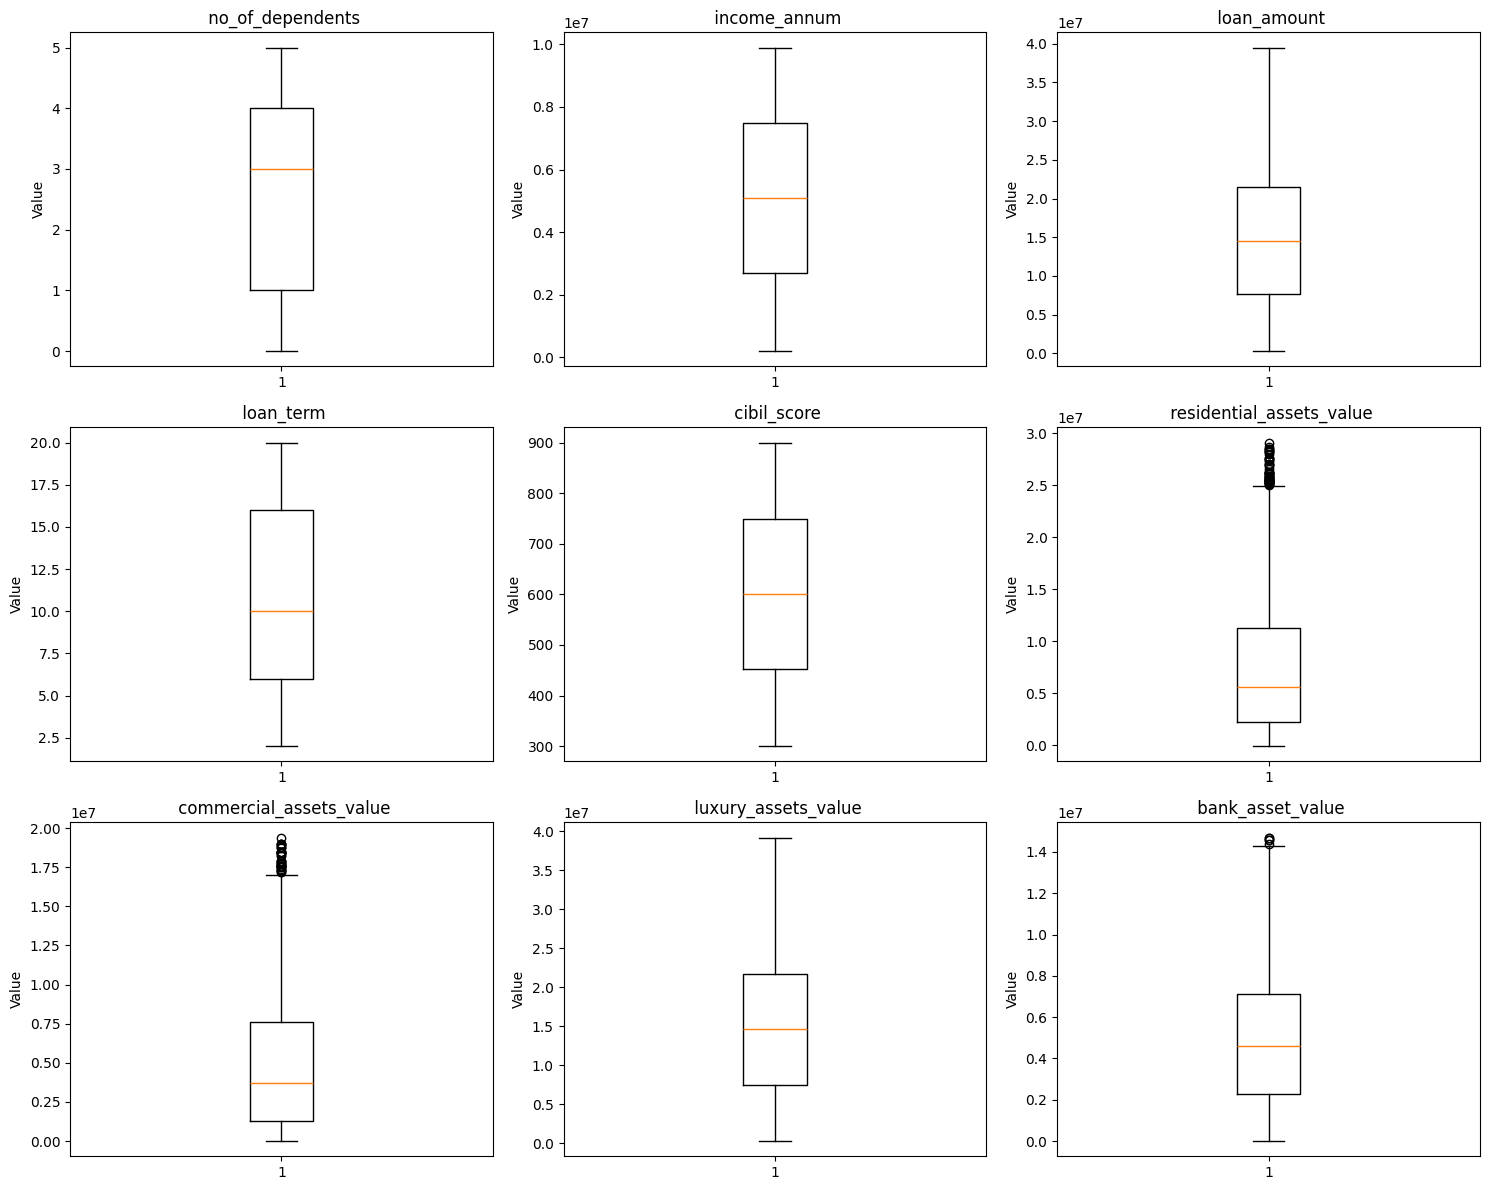

In [43]:
import matplotlib.pyplot as plt

data.describe()

numericalColumns = [" no_of_dependents", " income_annum", " loan_amount", " loan_term", " cibil_score", " residential_assets_value", " commercial_assets_value", " luxury_assets_value", " bank_asset_value"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numericalColumns):
    axes[i].boxplot(data[col])
    axes[i].set_title(col)
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()


Based on the boxplots produced during exploratory data analysis, the variables residential_assets_value, commercial_assets_value, and bank_asset_value displayed the most visible outliers. These variables represent different types of financial assets owned by the applicant and exhibit significant variability in their distributions. Because these features showed several extreme observations beyond the whiskers of the boxplots, they were selected as input features for the Local Outlier Factor (LOF) algorithm.

In [44]:
# Local Outlier Factor (LOF) for outlier detection
from sklearn.neighbors import LocalOutlierFactor

lof_columns = data[[" residential_assets_value", " commercial_assets_value", " bank_asset_value"]]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(lof_columns)

data["lof_outlier"] = lof_labels
print("Number of outliers detected by LOF:", (data["lof_outlier"] == -1).sum())

Number of outliers detected by LOF: 214


The LOF algorithm was applied to financial asset variables (residential_assets_value, commercial_assets_value, and bank_asset_value) to detect anomalous observations. Using a contamination parameter of 0.05, the algorithm identified 214 observations as potential outliers. These outliers represent approximately 5% of the dataset. Because these extreme observations could negatively affect the predictive model, they were removed from the dataset before training the decision tree classifier.

In [45]:
# Removing outliers detected by LOF

dataWithoutOutliers = data[data["lof_outlier"]!=-1]

print("Shape before removing outliers:", data.shape)
print("Shape after removing outliers:", dataWithoutOutliers.shape)

Shape before removing outliers: (4269, 14)
Shape after removing outliers: (4055, 14)


### Predictive Analysis using Decision Trees:

In [46]:

from sklearn.tree import DecisionTreeClassifier

# Baseline model using Decision Tree Classifier with Gini impurity, with the default parameters
baseline_tree = DecisionTreeClassifier(criterion="gini", random_state=42)


For the baseline classification model, the DecisionTreeClassifier method from scikit-learn was selected. Decision trees are well suited for this task because they can model non-linear decision boundaries and are easy to interpret. The baseline configuration uses the gini criterion, which is the default impurity measure in scikit-learn, while the other parameters were left at their default values. A random_state of 42 was specified to ensure reproducibility of the results.

### Feature Engineering:

In [47]:
# Creating a loan-to-income ratio feature
data["loan_to_income_ratio"] = data[" loan_amount"] / data[" income_annum"]

# Create a total assets feature by summing all asset columns
data["total_assets"] = data[" residential_assets_value"] + data[" commercial_assets_value"] + data[" luxury_assets_value"] + data[" bank_asset_value"]

Two additional features were constructed to enhance the predictive power of the model. The loan_income_ratio feature represents the proportion of the loan amount relative to the applicant’s income and provides insight into repayment capacity. The total_assets feature aggregates different types of assets into a single variable, capturing the overall financial strength of the applicant. These engineered features are expected to improve the model’s ability to distinguish between approved and rejected loan applications.

### Empirical Study:

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Config 1: Baseline model with all features except the outlier label and engineered features
X_baseline = data.drop(columns=[" loan_status", "lof_outlier", "loan_to_income_ratio", "total_assets"])
y = data[" loan_status"]

# creating test set with 15% of the data, and the rest for training
x_train_val, x_test, y_train_val, y_test = train_test_split(X_baseline, y, test_size=0.15, random_state=42, stratify=y)

# splitting the remaining training data into train and validation sets (80% train, 20% validation)
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val)

# 4-fold cross-validation using the baseline model on the training set
cross_validation_scores = cross_val_score(baseline_tree, x_train_val, y_train_val, cv=4, scoring="accuracy")
print("Cross-validation scores:", cross_validation_scores)


Cross-validation scores: [0.98125689 0.969129   0.96802646 0.97794928]


In [49]:
import numpy as np

print("Mean CV Accuracy: ", np.mean(cross_validation_scores))

Mean CV Accuracy:  0.974090407938258


Accuracy was selected as the evaluation metric, and the baseline model was evaluated using 4-fold cross-validation on the training and validation data. The baseline Decision Tree classifier achieved an average accuracy of approximately 97.4% using 4-fold cross-validation. The results indicate that the model performs well on the dataset even without any preprocessing such as outlier removal or feature construction. This high baseline performance suggests that the dataset contains strong predictive patterns.

In [50]:
# Config 2: Model with LOF outliers removed
X_lof = dataWithoutOutliers.drop(columns=[" loan_status", "lof_outlier"])
y_lof = dataWithoutOutliers[" loan_status"]

# creating test set with 15% of the data, and the rest for training and validation
X_train_val_o, X_test_o, y_train_val_o, y_test_o = train_test_split(
    X_lof, y_lof,
    test_size=0.15,
    random_state=42,
    stratify=y_lof
)

tree_outliers = DecisionTreeClassifier(criterion="gini", random_state=42)

# 4-fold cross-validation using the model with LOF outliers removed on the training set
cross_validation_scores_outliers = cross_val_score(tree_outliers, X_train_val_o, y_train_val_o, cv=4, scoring="accuracy")
print("Cross-validation scores with LOF outliers removed:", cross_validation_scores_outliers)


Cross-validation scores with LOF outliers removed: [0.96867749 0.98143852 0.97560976 0.97909408]


In [51]:
print("Mean CV Accuracy with LOF outliers removed: ", np.mean(cross_validation_scores_outliers))

Mean CV Accuracy with LOF outliers removed:  0.9762049605083389


The results show that removing outliers using the Local Outlier Factor (LOF) method slightly improved the model’s performance. The baseline model achieved an accuracy of approximately 97.4%, while the model trained on the dataset with outliers removed achieved approximately 97.6%. This improvement suggests that some extreme observations may have introduced noise into the model. However, the relatively small difference indicates that the dataset was already well-structured and that outliers did not have a major impact on the classification performance.

In [52]:
# Config 3: Model with engineered features added
X_features = data.drop(columns=[" loan_status", "lof_outlier"])
y_features = data[" loan_status"]

X_train_val_f, X_test_f, y_train_val_f, y_test_f = train_test_split(
    X_features, y_features,
    test_size=0.15,
    random_state=42,
    stratify=y_features
)

tree_features = DecisionTreeClassifier(criterion="gini", random_state=42)

# 4-fold cross-validation using the model with engineered features added on the training set
cross_validation_scores_features = cross_val_score(tree_features, X_train_val_f, y_train_val_f, cv=4, scoring="accuracy")
print("Cross-validation scores with engineered features added:", cross_validation_scores_features)

Cross-validation scores with engineered features added: [0.99558986 0.99007718 0.99338479 0.99228225]


In [53]:
print("Mean CV Accuracy with engineered features added: ", np.mean(cross_validation_scores_features))

Mean CV Accuracy with engineered features added:  0.9928335170893053


The addition of engineered features significantly improved the model’s performance. The Decision Tree classifier achieved an accuracy of approximately 99.28%, compared to 97.41% for the baseline model. This substantial improvement indicates that the constructed features, particularly loan_income_ratio and total_assets, capture important relationships in the data that were not explicitly represented in the original features. The loan-to-income ratio provides insight into an applicant’s repayment capacity, while total assets summarize overall financial strength. These features allow the model to make more effective splits, leading to improved classification performance.

In [54]:
# adding engineered features to the dataset without outliers
dataWithoutOutliers = dataWithoutOutliers.copy()
dataWithoutOutliers["loan_to_income_ratio"] = dataWithoutOutliers[" loan_amount"] / dataWithoutOutliers[" income_annum"]
dataWithoutOutliers["total_assets"] = dataWithoutOutliers[" residential_assets_value"] + dataWithoutOutliers[" commercial_assets_value"] + dataWithoutOutliers[" luxury_assets_value"] + dataWithoutOutliers[" bank_asset_value"]

# Config 4: Model with both LOF outliers removed and engineered features added and parameter tuning

X_lof_features = dataWithoutOutliers.drop(columns=[" loan_status", "lof_outlier"])
y_lof_features = dataWithoutOutliers[" loan_status"]

X_train_val_lof_f, X_test_lof_f, y_train_val_lof_f, y_test_lof_f = train_test_split(
    X_lof_features, y_lof_features,
    test_size=0.15,
    random_state=42,
    stratify=y_lof_features
)

tree_lof_features = DecisionTreeClassifier(criterion="gini", random_state=42, max_depth=5, min_samples_split=10)

cross_validation_scores_lof_features = cross_val_score(tree_lof_features, X_train_val_lof_f, y_train_val_lof_f, cv=4, scoring="accuracy")

print("Cross-validation scores with both LOF outliers removed and engineered features added and parameter tuning:", cross_validation_scores_lof_features)


Cross-validation scores with both LOF outliers removed and engineered features added and parameter tuning: [0.99187935 0.99419954 0.99535424 0.99535424]


In [55]:
print("Mean CV Accuracy with outliers removed and engineered features added and parameter tuning:", np.mean(cross_validation_scores_lof_features))

Mean CV Accuracy with outliers removed and engineered features added and parameter tuning: 0.9941968412060653


The final configuration, which combined outlier removal, feature construction, and parameter tuning, achieved the best performance with an accuracy of approximately 99.4%. This demonstrates that combining multiple preprocessing and modeling improvements can lead to incremental gains beyond the impact of feature engineering alone.

In [56]:
from sklearn.metrics import accuracy_score

# Test Set Evaluation for the best configuration (LOF + Feature Engineering + Parameter Tuning)

tree_lof_features.fit(X_train_val_lof_f, y_train_val_lof_f)

y_test_pred = tree_lof_features.predict(X_test_lof_f)

accuracy = accuracy_score(y_test_lof_f, y_test_pred)
print("Test set accuracy for the best configuration:", accuracy)

Test set accuracy for the best configuration: 0.9983579638752053


The final model was evaluated on the unseen test set after being trained on the combined training and validation data. The model achieved a test accuracy of approximately 99.84%, which is slightly higher than the cross-validation accuracy of 99.42%. This indicates that the model generalizes very well to unseen data and is not overfitting. The small difference between cross-validation and test performance suggests that the model has learned robust patterns from the dataset. Overall, the high accuracy on both validation and test sets demonstrates the effectiveness of the feature construction, outlier removal, and parameter tuning applied during the empirical study.

## References

Sharma, A. (n.d.). Loan Approval Prediction Dataset. Kaggle. Available at: https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset

Hellbuoy. (n.d.). Car Price Prediction: Multiple Linear Regression Dataset. Kaggle. Available at: https://www.kaggle.com/datasets/hellbuoy/car-price-prediction

OpenAI. (2026). ChatGPT (GPT-5.3). Utilized for assistance in data analysis, model implementation, and technical writing support. It was also used to further understand the different requirements for features (such as ranges, etc), and also to understand evaluation metrics like RMSE, MSE, accuracy, etc., and also decision trees

University of Ottawa. (2026). CSI4142 – Data Science, Week 8: Ensemble Approaches [Lecture slides] : these lecture slides were used as a guide and reference for the decision trees implementations